In [334]:
import rasterio
from rasterio import plot
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon, Point, box, MultiPoint
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.interpolate import griddata
import osmnx as ox
from matplotlib.ticker import StrMethodFormatter, MaxNLocator

In [335]:
from constants import GH_TREE_COORDS_FILEPATH
GHANA = ox.geocode_to_gdf('Ghana')

In [336]:
df = pd.read_excel(GH_TREE_COORDS_FILEPATH)
df.head(3)

,Pays,Région,Region code,Site Nb,Site Name,Tree N.,Tree Latitude,Tree Longitude
0,Ghana,Central,CR,1,FO05,T1,5.323065,-1.173049
1,Ghana,Central,CR,2,FO06,T1,5.431284,-1.157774
2,Ghana,Central,CR,3,FO07,T1,5.538543,-1.185850


In [337]:
# 155 sites, spread across 6 regions
print("# sites:", df["Site Name"].nunique())
print("# regions:", df["Région"].nunique())
print("# site per regions:")
df.groupby('Région')['Site Name'].nunique().sort_values()

# sites: 155
# regions: 6
# site per regions:


Région
Brong-Ahafo      15
Eastern          18
Central          20
Western-South    31
Ashanti          32
Western-North    39
Name: Site Name, dtype: int64

In [338]:
# No site spread across two regions
df.groupby('Site Name')['Région'].nunique().unique()

array([1])

In [339]:
# Each site has 5 trees
print("# trees per site:")
df.groupby('Site Name')['Tree N.'].count().unique()

# trees per site:


array([5])

In [340]:
# Add points 
df['point'] = df.apply(axis=1, func=lambda row: Point((row["Tree Longitude"], row["Tree Latitude"])))
df.head(3)

,Pays,Région,Region code,Site Nb,Site Name,Tree N.,Tree Latitude,Tree Longitude,point
0,Ghana,Central,CR,1,FO05,T1,5.323065,-1.173049,POINT (-1.173049 5.323065)
1,Ghana,Central,CR,2,FO06,T1,5.431284,-1.157774,POINT (-1.157774 5.431284)
2,Ghana,Central,CR,3,FO07,T1,5.538543,-1.185850,POINT (-1.18585 5.538543)


In [341]:
gdf = gpd.GeoDataFrame(df, geometry="point", crs="EPSG:4326")
gdf.head(3)

,Pays,Région,Region code,Site Nb,Site Name,Tree N.,Tree Latitude,Tree Longitude,point
0,Ghana,Central,CR,1,FO05,T1,5.323065,-1.173049,POINT (-1.17305 5.32306)
1,Ghana,Central,CR,2,FO06,T1,5.431284,-1.157774,POINT (-1.15777 5.43128)
2,Ghana,Central,CR,3,FO07,T1,5.538543,-1.185850,POINT (-1.18585 5.53854)


Text(0.5, 1.0, '155 plantations in Ghana')

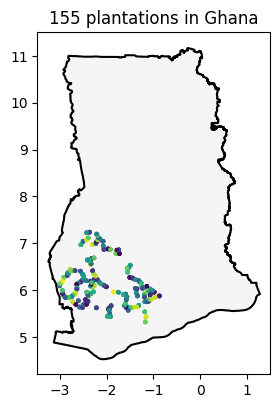

In [342]:
fig, ax = plt.subplots(figsize=(3, 5))

ghana_map.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=1.5)
gdf.plot(ax=ax, c=df["Site Name"].apply(hash), markersize=5, label='Coordinates')

plt.title(f"{df["Site Name"].nunique()} plantations in Ghana")

In [356]:
from dataclasses import dataclass

@dataclass
class Tree:
    point: Point
    
    def plot(self) -> None:
        f, axes = plt.subplots(1, 2, figsize=(6,5))

        # Plot full map
        GHANA.plot(ax=axes[0], color='whitesmoke', edgecolor='black', linewidth=1.5)

        # Plot single tree
        gdf = gpd.GeoDataFrame(geometry=[self.point])
        gdf.plot(ax=axes[0])

        # Plot zoomed-in version
        PADDING = 0.00001
        lon, lat = self.point.coords[0]
        min_lon, min_lat = lon -PADDING, lat - PADDING
        max_lon, max_lat = lon + PADDING, lat + PADDING

        GHANA.plot(ax=axes[1], color='whitesmoke', edgecolor='black', linewidth=1.5)
        gdf = gpd.GeoDataFrame(geometry=[self.point])
        gdf.plot(ax=axes[1])

        axes[1].set_xlim(min_lon, max_lon)
        axes[1].set_ylim(min_lat, max_lat)
        
@dataclass
class Site:
    trees: list[Tree]
    name: str
    region: str

    @property
    def polygon(self) -> Polygon:
        return MultiPoint([e.point for e in self.trees]).convex_hull

    @property
    def gdf(self) -> gpd.GeoDataFrame:
        return gpd.GeoDataFrame(geometry=[e.point for e in self.trees], crs="EPSG:4326")

    @property
    def gs(self) -> gpd.GeoDataFrame:
        return gpd.GeoSeries([self.polygon], crs="EPSG:4326")

    @property
    def area_m2(self) -> float:
        local_utm = self.gs.estimate_utm_crs()
        return self.gs.to_crs(local_utm).area.iloc[0]
        
    def plot(self) -> None:
        f, axes = plt.subplots(1, 2, figsize=(5,6))

        for ax in axes:
            ax.xaxis.set_major_locator(MaxNLocator(nbins=2))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=2))
            ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.5f}'))
            ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.5f}'))

        # Plot full map
        GHANA.plot(ax=axes[0], color='whitesmoke', edgecolor='black', linewidth=1.5)
        self.gdf.plot(ax=axes[0])
        axes[0].set_title(f"Plantation {self.name}\n (Region: {self.region})")

        # Plot zoomed-in version
        GHANA.plot(ax=axes[1], color='whitesmoke', edgecolor='black', linewidth=1.5)
        self.gs.plot(ax=axes[1],color='lightgreen', alpha=0.5)
        self.gdf.plot(ax=axes[1])
        
        min_lon, min_lat, max_lon, max_lat = self.polygon.bounds
        PADDING = 0.00001
        min_lon -= PADDING
        min_lat -= PADDING 
        max_lon += PADDING 
        max_lat += PADDING 

        axes[1].set_xlim(min_lon, max_lon)
        axes[1].set_ylim(min_lat, max_lat)
        axes[1].set_title(f"{len(self.trees)} trees\n spanning {self.area_m2:.1f} m2")

        plt.tight_layout()
        plt.show()


In [357]:
sites = []
for site_name, row_idxs in df.groupby('Site Name').groups.items():
    trees = []
    for _, row in df.iloc[row_idxs].iterrows():
        lon_lat = (row["Tree Longitude"], row["Tree Latitude"])
        t = Tree(point=Point(lon_lat))
        trees.append(t)

    s = Site(trees=trees, name=site_name, region=row['Région'])
    sites.append(s)

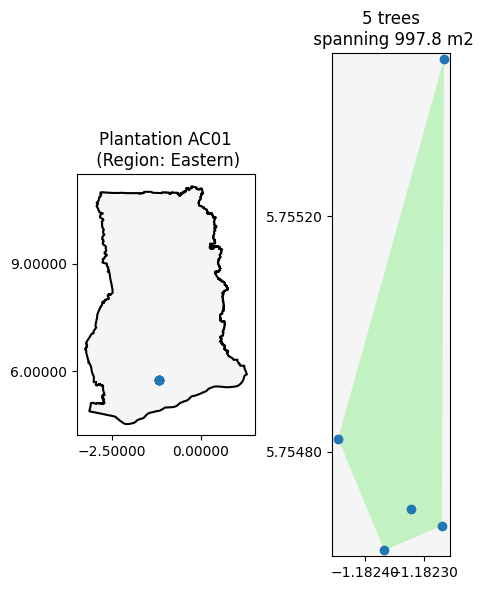

In [359]:
sites[0].plot()